In [1]:
import pandas as pd
from scipy import stats

In [2]:
player_season = pd.read_csv('nba_player_season_analysis.csv')
team = pd.read_csv('team_stats.csv')

In [3]:
## adding playoff team column to team dataframe
playoff_team ={'2022-23': ['DEN', 'MIN', 'PHX', 'LAC', 'GSW', 'SAC', 'MEM', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ATL', 'PHI', 'BKN'],
                '2023-24': ['DEN', 'MIN', 'DAL', 'LAC', 'PEL', 'OKC', 'PHX', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ORL', 'PHI', 'IND'],
                '2024-25': ['DEN', 'MIN', 'MEM', 'LAC', 'GSW', 'OKC', 'HOU', 'LAL', 'MIL', 'MIA', 'CLE', 'NYK', 'BOS', 'ORL', 'IND', 'DET'],
                '2025-26': ['DEN', 'MIN', 'OKC', 'LAC', 'SAS', 'POR', 'PHX', 'LAL', 'ORL', 'DET', 'CLE', 'NYK', 'BOS', 'TOR', 'PHI', 'ATL']}
team['playoff_team'] = team.apply(lambda row: row['team'] in playoff_team.get(row['season'], []), axis=1)


In [4]:
## point differential and win percentage columns
team['point_diff'] = (team['points_pg'] - team['opponent_points_pg'])
team['win_pct'] = team['wins'] / (team['wins'] + team['loses'])

In [5]:
## playoff team stats compared to non-playoff team stats
stats = ['wins',
         'win_pct',
         'points_pg',
         'opponent_points_pg',
         'point_diff',
         'avg_fg_pct',
         'avg_three_point_pct',
         'avg_offensive_rebounds',
         'avg_defensive_rebounds',
         'avg_apg',
         'avg_spg',
         'avg_bpg',
         'off_rating_est',
         'def_rating_est',
         'net_rating']

team.groupby('playoff_team')[stats].mean()

,wins,win_pct,points_pg,opponent_points_pg,point_diff,avg_fg_pct,avg_three_point_pct,avg_offensive_rebounds,avg_defensive_rebounds,avg_apg,avg_spg,avg_bpg,off_rating_est,def_rating_est,net_rating
playoff_team,,,,,,,,,,,,,,,
False,30.929825,0.377193,112.950372,117.014332,-4.063960,0.464895,0.353709,11.079588,32.422121,26.076377,7.736633,4.759311,110.255060,114.227926,-3.972870
True,50.111111,0.611111,116.059235,112.382306,3.676929,0.480287,0.367094,10.682730,33.225892,26.539292,7.947341,4.985281,114.143859,110.549356,3.594502


In [6]:
## difference between playoff team stats and non-playoff team stats
playoff_team_avg = team[team['playoff_team'] == True][stats].mean()
non_playoff_team_avg = team[team['playoff_team'] == False][stats].mean()
difference = playoff_team_avg - non_playoff_team_avg
difference.sort_values(ascending=False).round(2)

wins                      19.18
point_diff                 7.74
net_rating                 7.57
off_rating_est             3.89
points_pg                  3.11
avg_defensive_rebounds     0.80
avg_apg                    0.46
win_pct                    0.23
avg_bpg                    0.23
avg_spg                    0.21
avg_fg_pct                 0.02
avg_three_point_pct        0.01
avg_offensive_rebounds    -0.40
def_rating_est            -3.68
opponent_points_pg        -4.63
dtype: float64

In [7]:
## playoff team stats compared to non-playoff team stats by season
team.groupby(['season', 'playoff_team'])[stats].mean().round(2)

wins  win_pct  points_pg  opponent_points_pg  \
season  playoff_team                                                  
2022-23 False         33.07     0.40     113.46              116.20   
        True          47.94     0.58     115.76              113.36   
2023-24 False         31.00     0.38     112.48              116.42   
        True          51.00     0.62     115.94              112.00   
2024-25 False         29.93     0.36     111.77              116.78   
        True          50.69     0.62     115.62              111.24   
2025-26 False         29.71     0.36     114.13              118.70   
        True          50.88     0.62     116.90              112.90   

                      point_diff  avg_fg_pct  avg_three_point_pct  \
season  playoff_team                                                
2022-23 False              -2.75        0.47                 0.35   
        True                2.40        0.48                 0.37   
2023-24 False              -3.94        0.46                 0.36   
        True                3.94        0.49                 0.37   
2024-25 False              -5.01        0.46                 0.35   
        True                4.38        0.48                 0.37   
2025-26 False              -4.57        0.46                 0.36   
        True                4.00        0.48                 0.36   

                      avg_offensive_rebounds  avg_defensive_rebounds  avg_apg  \
season  playoff_team                                                            
2022-23 False                          10.65                   32.45    24.65   
        True                           10.25                   33.49    25.90   
2023-24 False                          11.06                   32.60    26.54   
        True                           10.04                   33.37    26.80   
2024-25 False                          11.26                   32.50    26.30   
        True                           10.99                   33.42    26.77   
2025-26 False                          11.34                   32.12    26.78   
        True                           11.41                   32.63    26.70   

                      avg_spg  avg_bpg  off_rating_est  def_rating_est  \
season  playoff_team                                                     
2022-23 False            7.42     4.61          110.77          113.46   
        True             7.18     4.69          113.39          111.03   
2023-24 False            7.40     4.92          110.27          114.14   
        True             7.55     5.37          114.81          110.95   
2024-25 False            7.98     4.82          109.28          114.18   
        True             8.40     4.93          113.81          109.53   
2025-26 False            8.18     4.68          110.69          115.14   
        True             8.63     4.98          114.61          110.71   

                      net_rating  
season  playoff_team              
2022-23 False              -2.69  
        True                2.35  
2023-24 False              -3.86  
        True                3.86  
2024-25 False              -4.90  
        True                4.29  
2025-26 False              -4.45  
        True                3.90

In [8]:
## player stats on playoff vs non-playoff teams  by season
player_analysis = player_season.merge(team[['season', 'team', 'playoff_team']],
    on=['season', 'team'],
    how='left')
player_analysis.groupby(['season', 'playoff_team'])[['points_pg', 
                                                     'rebounds_pg', 
                                                     'assists_pg', 
                                                     'ts_pct', 
                                                     'effective_fg_pct', 
                                                     'usage_rate', 
                                                     'ast_pct', 
                                                     'reb_pct',
                                                     'tov_pct']].mean().round(2)

points_pg  rebounds_pg  assists_pg  ts_pct  \
season  playoff_team                                               
2022-23 False              9.03         3.46        1.99    0.56   
        True               9.20         3.61        2.13    0.56   
2023-24 False              8.46         3.50        2.03    0.54   
        True               8.38         3.25        1.97    0.55   
2024-25 False              9.22         3.71        2.18    0.55   
        True               8.58         3.49        1.99    0.55   
2025-26 False              9.58         3.83        2.24    0.56   
        True               8.76         3.35        2.05    0.57   

                      effective_fg_pct  usage_rate  ast_pct  reb_pct  tov_pct  
season  playoff_team                                                           
2022-23 False                     0.53        0.18     0.13     0.09     0.12  
        True                      0.54        0.18     0.14     0.11     0.13  
2023-24 False                     0.51        0.17     0.14     0.10     0.12  
        True                      0.53        0.18     0.14     0.10     0.12  
2024-25 False                     0.52        0.18     0.15     0.10     0.13  
        True                      0.52        0.18     0.14     0.10     0.12  
2025-26 False                     0.53        0.18     0.15     0.10     0.13  
        True                      0.54        0.17     0.14     0.10     0.12

In [9]:
## player stats on playoff vs non-playoff teams  overall

player_analysis.groupby('playoff_team')[
    ['points_pg', 
     'rebounds_pg', 
     'assists_pg', 
     'ts_pct', 
     'effective_fg_pct', 
     'usage_rate', 
     'ast_pct', 
     'reb_pct',
     'tov_pct']].mean().round(2)

,points_pg,rebounds_pg,assists_pg,ts_pct,effective_fg_pct,usage_rate,ast_pct,reb_pct,tov_pct
playoff_team,,,,,,,,,
False,9.06,3.63,2.11,0.55,0.52,0.18,0.14,0.1,0.12
True,8.73,3.42,2.04,0.56,0.53,0.18,0.14,0.1,0.12


In [ ]:
filtered_players = player_analysis[player_analysis['minutes_pg'] > 15]
playoff_players = filtered_players[(filtered_players['playoff_team'] == True)]
non_playoff_players = filtered_players[(filtered_players['playoff_team'] == False)]
metrics = ['points_pg', 'ts_pct', 'effective_fg_pct', 'usage_rate', 'tov_pct']
test_results = []

for metric in metrics:
    playoff_vec = playoff_players[metric].dropna()
    non_playoff_vec = non_playoff_players[metric].dropna()
    
    # Run the two-sample t-test
    t_stat, p_val = scipy_stats.ttest_ind(playoff_vec, non_playoff_vec)
    
    test_results.append({
        'Metric': metric,
        'Playoff Mean': playoff_vec.mean(),
        'Non-Playoff Mean': non_playoff_vec.mean(),
        'Mean Diff': playoff_vec.mean() - non_playoff_vec.mean(),
        'p-value': p_val,
        'Statistically Significant': p_val < 0.05
    })

# 4. Display the results
results_df = pd.DataFrame(test_results).round(4)
print(results_df)




AttributeError: 'list' object has no attribute 'ttest_ind'

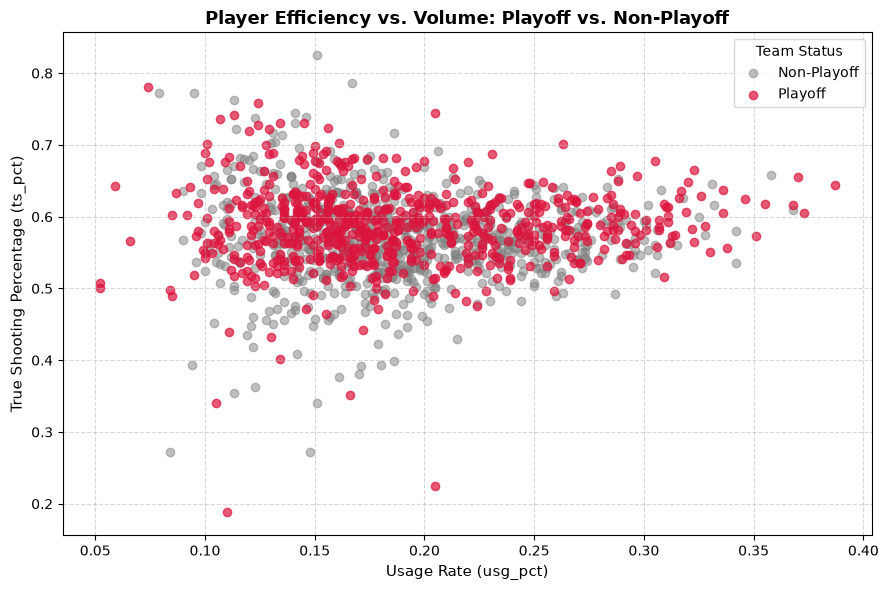

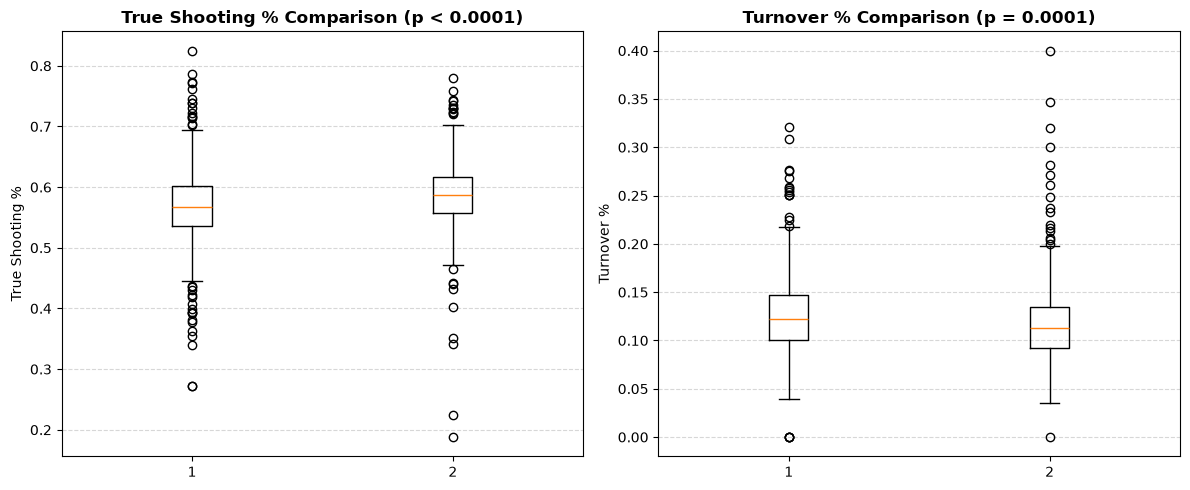

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
plt.scatter(non_playoff_players['usage_rate'], non_playoff_players['ts_pct'], color='gray', alpha=0.5, label='Non-Playoff')
plt.scatter(playoff_players['usage_rate'], playoff_players['ts_pct'], color='crimson', alpha=0.7, label='Playoff')

# Titles and Labels
plt.title('Player Efficiency vs. Volume: Playoff vs. Non-Playoff', fontsize=13, fontweight='bold')
plt.xlabel('Usage Rate (usg_pct)', fontsize=11)
plt.ylabel('True Shooting Percentage (ts_pct)', fontsize=11)
plt.legend(title='Team Status')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Create side-by-side subplot figures
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box Plot 1: True Shooting %
ts_data = [non_playoff_players['ts_pct'].dropna(), playoff_players['ts_pct'].dropna()]
axes[0].boxplot(ts_data, label=['Non-Playoff', 'Playoff'])
axes[0].set_title('True Shooting % Comparison (p < 0.0001)', fontweight='bold')
axes[0].set_ylabel('True Shooting %')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Box Plot 2: Turnover %
tov_data = [non_playoff_players['tov_pct'].dropna(), playoff_players['tov_pct'].dropna()]
axes[1].boxplot(tov_data, label=['Non-Playoff', 'Playoff'])
axes[1].set_title('Turnover % Comparison (p = 0.0001)', fontweight='bold')
axes[1].set_ylabel('Turnover %')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
playoff_team = team[team['playoff_team'] == True]
non_playoff_team = team[team['playoff_team'] == False]
team_metrics = ['off_rating_est', 'def_rating_est', 'net_rating']
team_results = []
for metric in team_metrics:
    playoff_vec = playoff_team[metric]
    non_playoff_vec = non_playoff_team[metric]
    
    # Run the two-sample t-test
    t_stat, p_val = stats.ttest_ind(playoff_vec, non_playoff_vec)
    
    team_results.append({
        'Metric': metric,
        'Playoff Mean': playoff_vec.mean(),
        'Non-Playoff Mean': non_playoff_vec.mean(),
        'Mean Diff': playoff_vec.mean() - non_playoff_vec.mean(),
        'p-value': p_val,
        'Statistically Significant': p_val < 0.05
    })
team_results_df = pd.DataFrame(team_results).round(4)
print(team_results_df)

           Metric  Playoff Mean  Non-Playoff Mean  Mean Diff  p-value  \
0  off_rating_est      114.1439          110.2551     3.8888      0.0   
1  def_rating_est      110.5494          114.2279    -3.6786      0.0   
2      net_rating        3.5945           -3.9729     7.5674      0.0   

   Statistically Significant  
0                       True  
1                       True  
2                       True  
